In [1]:
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
from matplotlib.ticker import ScalarFormatter, LogFormatter, FuncFormatter

from Functions import *
import MetricMapping

# Access the mappings:
type_mapping = MetricMapping.type_mapping
name_mapping = MetricMapping.name_mapping

## Prepare the data
### Get the data

In [2]:
transformed_minmax_scaled = pd.read_csv("../Data/NotScaled_RawVsDMC.csv")

transformed_minmax_scaled['peak_mean_ratio_DMC_10'] = transformed_minmax_scaled['peak_mean_ratio_scaled_DMC_10']
transformed_minmax_scaled['relative_amp_DMC_10'] = transformed_minmax_scaled['relative_amp_scaled_DMC_10']
transformed_minmax_scaled['peak_mean_ratio'] = transformed_minmax_scaled['peak_mean_ratio_scaled']
transformed_minmax_scaled['relative_amp'] = transformed_minmax_scaled['relative_amp_scaled']

cols_to_delete = ['relative_amp_scaled', 'relative_amp_scaled_DMC_10',
    'frac_q1_wi', "frac_q2_wi", "frac_q3_wi", "frac_q4_wi",
                  "duration",
    'peak_mean_ratio_scaled', 'peak_mean_ratio_scaled_DMC_10','min_intensity', 'min_intensity_DMC_10',
     'm1_DMC_10', 'm2_DMC_10', 'm3_DMC_10','m4_DMC_10', 'm5_DMC_10', 'max_intensity', 'max_intensity_DMC_10']

for col in cols_to_delete:
    del transformed_minmax_scaled[col]

column_names=transformed_minmax_scaled.columns

### Get a list of metrics

In [3]:
categorical_metrics = ['3rd_ARR',  '3rd_rcg',  '3rd_w_peak', '4th_w_peak', '5th_w_peak', 'third_ppr', '3rd_w_most', 
                       '4th_w_most', '5th_w_most']
continuous_metrics = [metric for metric in column_names if metric not in categorical_metrics]
intermittency_metrics = ['intermittency', 'event_dry_ratio']

metric_base_names = {col.replace(suffix, '') for col in transformed_minmax_scaled.columns  for suffix in ['_DMC_10']  if col.endswith(suffix)}

### Calculate statistics on the data

In [4]:
summary_df = compute_metric_sensitivity_bynormalisation(df=transformed_minmax_scaled,
    continuous_metrics=continuous_metrics,
    categorical_metrics=categorical_metrics)
summary_df["type2"] = summary_df["metric"].map(type_mapping)

# Sort by type_2 and descending rank_corr
summary_df = summary_df.sort_values(
    by=["type2", "rank_corr"],
    key=lambda col: (
        col.map({'Asymmetry': 0, 'Peakiness': 1, 'Concentration': 2, 'Intermittency': 3})
        if col.name == "type2" else -col))

### Get versions of the data split by metric type`

In [5]:
df_intermittency = summary_df[summary_df["type2"] == "Intermittency"]
df_other = summary_df[(summary_df["type2"] != "Intermittency") & (summary_df["type"] != "categorical")]
df_categorical = summary_df[summary_df["type"] == "categorical"]
df_continuous =  pd.concat([df_other, df_intermittency])

## Plotting
### Scatter plot

/nfs/a321/gy17m2a/anaconda_install/anaconda3/envs/ukcp18/lib/python3.7/site-packages/ipykernel_launcher.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


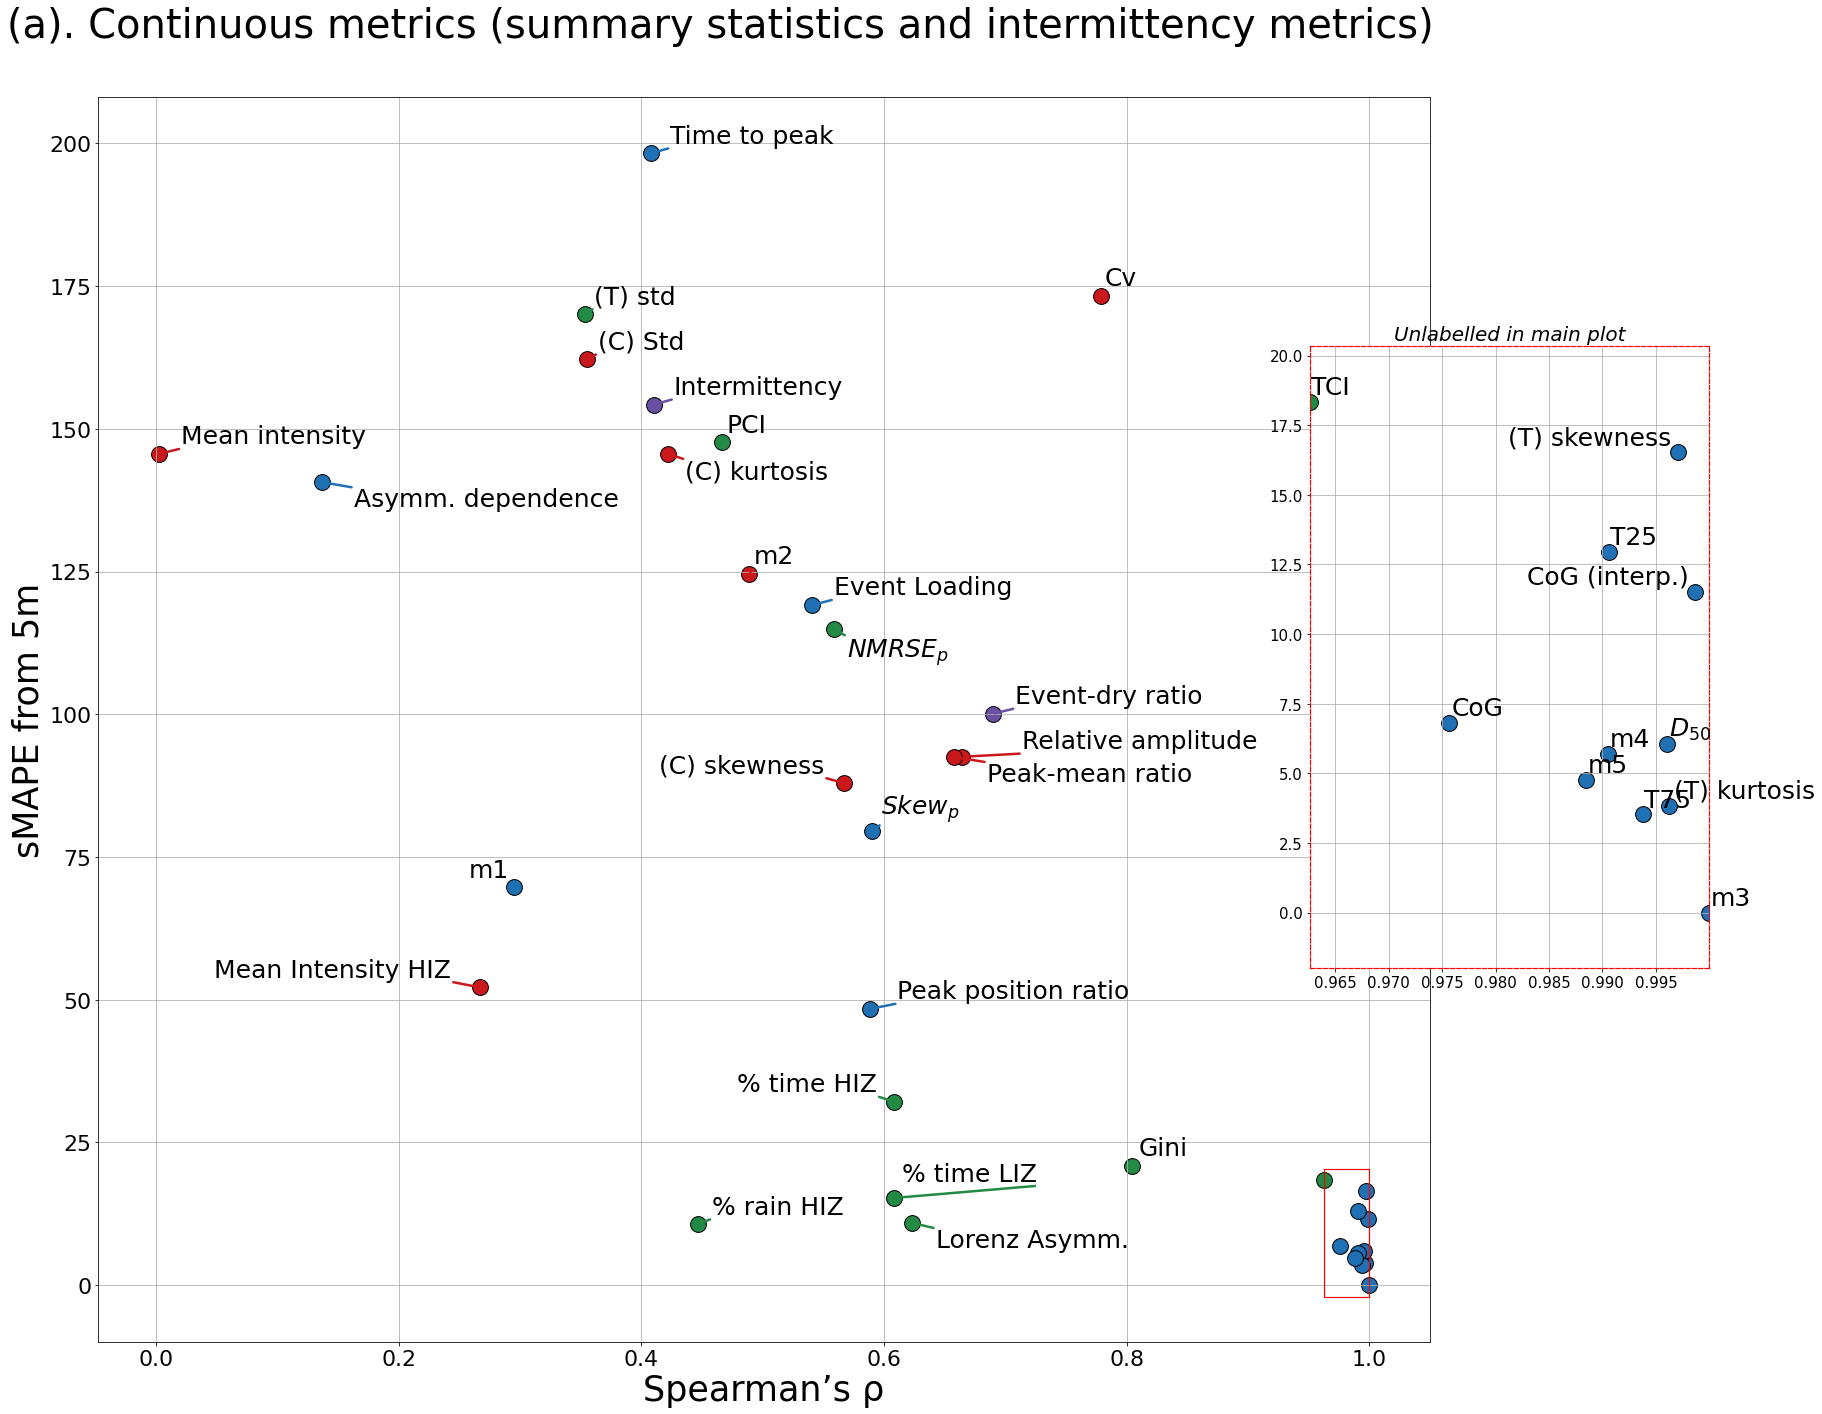

In [26]:
size=250
labelsize = 25
texts = []
face_colors = []
original_positions = []
marker = 'o'

# Determine which points to label
mask_label = ~((df_continuous["rank_corr"] > 0.96) & (df_continuous["val_diff"] < 25))
df_label = df_continuous[mask_label]
df_skip = df_continuous[~mask_label]

fig, ax = plt.subplots(figsize=(20, 20))

# --- Main plot: plot all points ---
for _, row in df_continuous.iterrows():
    face_color = type_color_map_2[row['type2']][2]
    ax.scatter(row["rank_corr"], row["val_diff"],facecolor=face_color,edgecolor='black',marker=marker,s=size, alpha=1)
ax.tick_params(axis='both', which='major', labelsize=22)

# --- Add labels to selected points ---
for _, row in df_label.iterrows():
    face_color = type_color_map_2[row['type2']][2]
    original_positions.append((row["rank_corr"], row["val_diff"]))
    face_colors.append(face_color)
    
    txt = ax.text(row["rank_corr"], row["val_diff"],name_mapping[row["metric"]],
                  fontsize=labelsize, color='black')
    texts.append(txt)

# --- Adjust labels ---
adjust_text(
    texts, ax=ax,
    arrowprops=None,
    expand_text=(1.05, 1.2),
    expand_points=(1.2, 1.4),
    only_move={'points': 'xy', 'text': 'xy'},
    force_points=0.2,
    force_text=0.2,)

# --- Draw colored arrows ---
for txt, (x0, y0), face_color in zip(texts, original_positions, face_colors):
    x1, y1 = txt.get_position()
    ax.annotate("",
        xy=(x0, y0), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='-', color=face_color, lw=2.5))

# --- Inset plot for skipped labels ---
ax_inset = inset_axes(
    ax,
    width="30%", height="50%",
    loc='upper left',
    bbox_to_anchor=(0.91, -0.2, 1, 1),  # Shifted to the right of ax
    bbox_transform=ax.transAxes,
    borderpad=0.0)


# Make the inset axes border red to match the rectangle
for spine in ax_inset.spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(1.2)
    spine.set_linestyle('--')

texts_inset = []
positions_inset = []
face_colors_inset = []

for _, row in df_skip.iterrows():
    face_color = type_color_map_2[row['type2']][2]
    ax_inset.scatter(
        row["rank_corr"], row["val_diff"],
        facecolor=face_color,
        edgecolor='black',
        marker=marker,
        s=size * 1,
        alpha=1
    )
    positions_inset.append((row["rank_corr"], row["val_diff"]))
    face_colors_inset.append(face_color)
    
    txt = ax_inset.text(
        row["rank_corr"], row["val_diff"],name_mapping[row["metric"]],
        fontsize=labelsize * 1, color='black'
    )
    texts_inset.append(txt)

# Adjust inset labels to avoid overlaps
adjust_text(
    texts_inset, ax=ax_inset,
    expand_text=(1.05, 1.2),
    expand_points=(1.2, 1.4),
    only_move={'points': 'xy', 'text': 'xy'},
    force_points=0.1,
    force_text=0.1,
    arrowprops=None)

# Optionally: colored arrows in inset
for txt, (x0, y0), face_color in zip(texts_inset, positions_inset, face_colors_inset):
    x1, y1 = txt.get_position()
    ax_inset.annotate("",
        xy=(x0, y0), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='-', color=face_color, lw=1))
    
# Tidy inset plot
ax_inset.set_title("Unlabelled in main plot", fontsize=20, fontstyle="italic")
ax_inset.tick_params(labelsize=5)
ax_inset.grid(True)

# Match inset limits for spatial consistency
ax_inset.set_xlim(df_skip["rank_corr"].min(), df_skip["rank_corr"].max())
ax_inset.set_ylim(df_skip["val_diff"].min() - 2, df_skip["val_diff"].max() + 2)

# --- Main axes setup ---
ax.set_xlabel("Spearman’s ρ", fontsize=35)
ax.set_ylabel("sMAPE from 5m", fontsize=35)
ax.grid(True)

ax_inset.tick_params(axis='both', which='major', labelsize=15)

# Coordinates & size of inset zoom region (same as inset x/y limits)
x0, x1 = ax_inset.get_xlim()
y0, y1 = ax_inset.get_ylim()

# Create a rectangle patch
rect = patches.Rectangle(
    (x0, y0),         # bottom-left corner
    x1 - x0,          # width
    y1 - y0,          # height
    linewidth=1.2,
    edgecolor='red',  # color of the box outline
    facecolor='none', # transparent fill
    linestyle='-',
    zorder=5          # draw on top
)

# Add the rectangle to the main axes
ax.add_patch(rect)

# Define corners of rectangle
corners = [(x0, y0), (x0, y1), (x1, y1), (x1, y0)]
# Define corresponding corners in inset axes (in data coords)
inset_corners = [
    (ax_inset.get_xlim()[0], ax_inset.get_ylim()[0]),
    (ax_inset.get_xlim()[0], ax_inset.get_ylim()[1]),
    (ax_inset.get_xlim()[1], ax_inset.get_ylim()[1]),
    (ax_inset.get_xlim()[1], ax_inset.get_ylim()[0])]

for (x_main, y_main), (x_in, y_in) in zip(corners, inset_corners):
    line = Line2D([x_main, x_in], [y_main, y_in],
                  transform=ax.transData,
                  color='red', linestyle='--', linewidth=2)
    fig.add_artist(line)


fig.suptitle("(a). Continuous metrics (summary statistics and intermittency metrics)", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
fig.savefig("../Figures/Scatter_continuous_DMC10.png", dpi=300, facecolor='white', bbox_inches='tight')

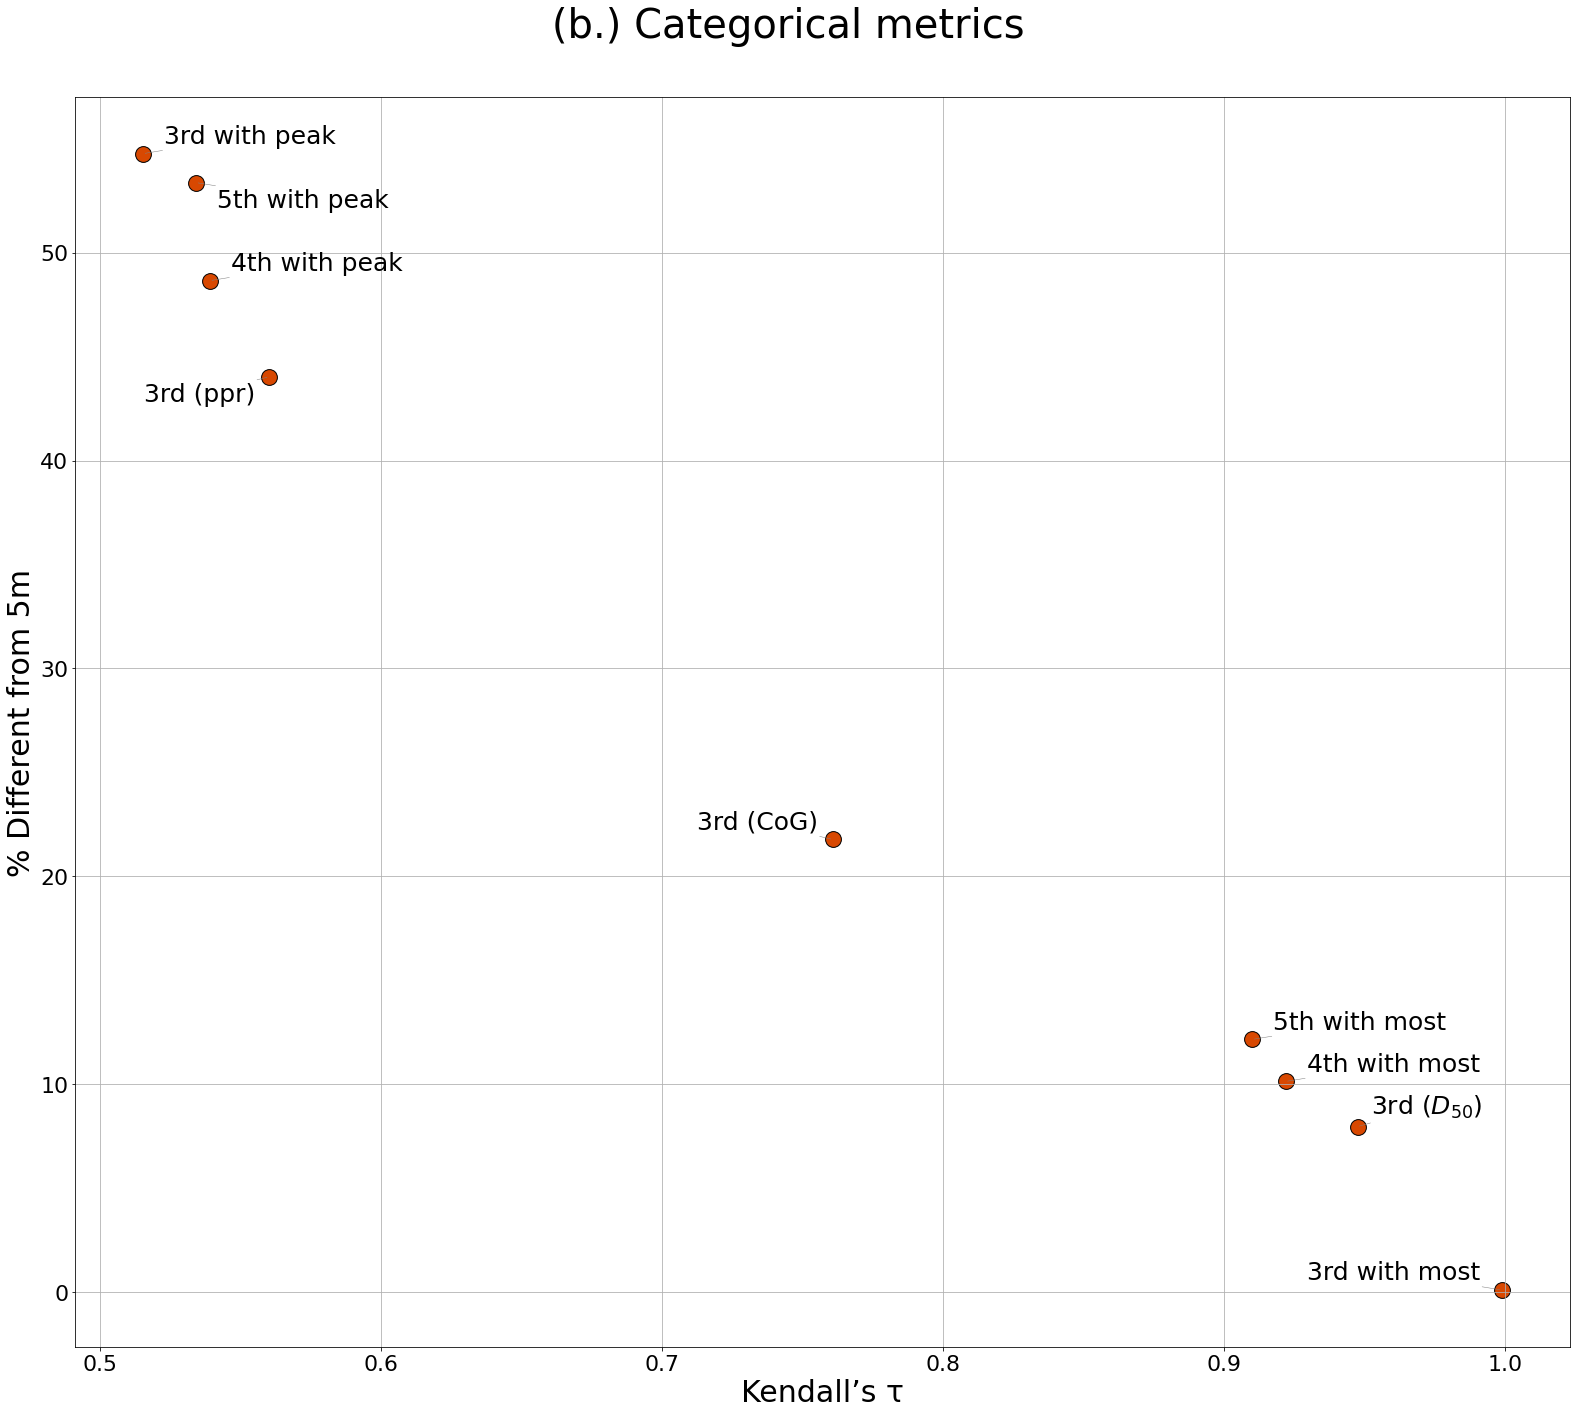

In [25]:
fig, ax = plt.subplots(figsize=(22, 20))  # Expanded canvas

marker = 'o'
size = 250
labelsize = 25
texts = []

for _, row in df_categorical.iterrows():
    # Scatter point
    ax.scatter(
        row["rank_corr"],
        row["val_diff"],
        facecolor=type_color_map_2[row['type2']][2],
        edgecolor='black',
        marker=marker,
        s=size,
        alpha=1)
    # Clean label name
    metric_name = name_mapping[row["metric"]]
    
    # Create text object (to be adjusted later)
    texts.append(
        ax.text(row["rank_corr"], row["val_diff"], metric_name, fontsize=labelsize))
ax.tick_params(axis='both', which='major', labelsize=22)
# Axes labels
ax.set_xlabel("Kendall’s τ", fontsize=30)
ax.set_ylabel("% Different from 5m", fontsize=30)
ax.grid(True)
# Adjust text to avoid overlaps
adjust_text(texts,
     ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.05, 1.2),
    expand_points=(1.2, 1.4),
    only_move={'points': 'xy', 'text': 'xy'},
    force_points=0.5,
    force_text=1.2)

fig.suptitle("(b.) Categorical metrics", fontsize=40)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("../Figures/Scatter_categorical_DMC10.png", dpi=300, facecolor='white', bbox_inches='tight')

### Combine figures into one

In [27]:
from PIL import Image, ImageDraw, ImageFont
import math

def combine_images_grid(image_paths, out_path,
                        ncols=6, pad=10, bg_color=(255,255,255),
                        dpi=300, labels=None):
    imgs = [Image.open(p).convert("RGB") for p in image_paths]
    widths, heights = zip(*(i.size for i in imgs))
    cell_w = max(widths)
    cell_h = max(heights)

    n = len(imgs)
    nrows = -(-n // ncols)   # ceiling division
    out_w = ncols*cell_w + pad*(ncols+1)
    out_h = nrows*cell_h + pad*(nrows+1)
    canvas = Image.new("RGB", (out_w, out_h), bg_color)

    for idx, img in enumerate(imgs):
        r = idx // ncols
        c = idx % ncols
        x = pad + c*(cell_w + pad)
        y = pad + r*(cell_h + pad)
        # center image in cell
        img_w, img_h = img.size
        paste_x = x + (cell_w - img_w)//2
        paste_y = y + (cell_h - img_h)//2
        canvas.paste(img, (paste_x, paste_y))

        # optional label under the image
        if labels:
            draw = ImageDraw.Draw(canvas)
            try:
                font = ImageFont.truetype("DejaVuSans.ttf", 12)
            except Exception:
                font = ImageFont.load_default()
            text = labels[idx]
            tw, th = draw.textsize(text, font=font)
            draw.rectangle([paste_x, paste_y+img_h - th - 6, paste_x + tw + 6, paste_y+img_h],
                           fill=(255,255,255))
            draw.text((paste_x+3, paste_y+img_h - th - 4), text, fill=(0,0,0), font=font)

    # save (PNG or PDF). dpi metadata set to (dpi,dpi)
    canvas.save(out_path, dpi=(dpi, dpi))
    
# Collect all PNGs (adjust pattern/order as needed)
files = sorted(glob.glob("../Figures/Scatter_continuous_DMC10.png")) + sorted(glob.glob("../Figures/Scatter_categorical_DMC10.png")) 

combine_images_grid(files, "../Figures/metrics_combined_scatter_DMC_10.png", ncols=2, pad=12, dpi=300)